<a href="https://colab.research.google.com/github/isa-ulisboa/greends-pml/blob/main/notebooks/T2_breast_cancer_wisconsin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Read data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [ ]:
import pandas as pd
import os

# List files in the dataset directory to find the CSV
file_list = os.listdir(path)
csv_file = [f for f in file_list if f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, csv_file))
print(f"DataFrame created with {len(df)} rows and {len(df.columns)} columns.")
df.head()

DataFrame created with 569 rows and 33 columns.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Pre-process data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Discard 'id' and 'Unnamed: 32' columns
df_processed = df.drop(columns=['id', 'Unnamed: 32'])

# Define response variable (y) and predictors (X)
X = df_processed.drop(columns=['diagnosis'])
y = df_processed['diagnosis']

# Convert 'diagnosis' to numerical (M=1, B=0)
y = y.map({'M': 1, 'B': 0})

# Split data into training and testing sets first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize predictors (fit only on X_train, then transform both X_train and X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train_scaled: (455, 30)
Shape of X_test_scaled: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


# Fit logistic regression over train set

In [ ]:
import numpy as np

class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iterations):
            # Linear model output
            linear_model = np.dot(X, self.weights) + self.bias
            # Apply sigmoid activation function
            y_predicted = self._sigmoid(linear_model)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        # Convert probabilities to binary predictions (0 or 1)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

# Instantiate and fit the model
model = LogisticRegression(learning_rate=0.01, n_iterations=1000)
model.fit(X_train_scaled, y_train)

print("Logistic Regression model fitted successfully.")
print(f"Learned Weights: {model.weights[:5]}...") # Print first 5 weights
print(f"Learned Bias: {model.bias}")

Logistic Regression model fitted successfully.
Learned Weights: [0.37482698 0.35458056 0.37121819 0.37105218 0.14943464]...
Learned Bias: -0.3546612737779515


# Estimate model's accuracy

Accuracy on the test set: 0.9825


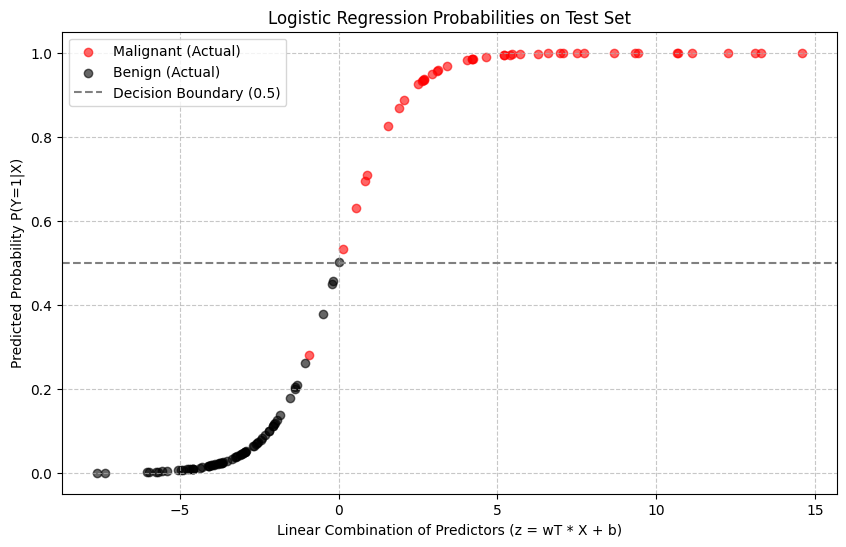

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: {accuracy:.4f}")

# --- Plotting section ---

# Calculate the linear combination of predictors (z) for the test set
linear_combination = np.dot(X_test_scaled, model.weights) + model.bias

# Calculate probabilities (y_predicted_prob) for the test set
# We need to access the sigmoid function, which is a private method in our class.
# A more robust way would be to make a public method `predict_proba` in the class.
# For now, we can re-implement it directly or access the private method.
# Let's directly calculate probabilities using the sigmoid function
predicted_probabilities = 1 / (1 + np.exp(-linear_combination))

# Create the plot
plt.figure(figsize=(10, 6))

# Plot observed dots for class M (Malignant = 1)
plt.scatter(
    linear_combination[y_test == 1],
    predicted_probabilities[y_test == 1],
    color='red',
    label='Malignant (Actual)',
    alpha=0.6
)

# Plot observed dots for class B (Benign = 0)
plt.scatter(
    linear_combination[y_test == 0],
    predicted_probabilities[y_test == 0],
    color='black',
    label='Benign (Actual)',
    alpha=0.6
)

plt.axhline(0.5, color='gray', linestyle='--', label='Decision Boundary (0.5)')
plt.xlabel('Linear Combination of Predictors (z = wT * X + b)')
plt.ylabel('Predicted Probability P(Y=1|X)')
plt.title('Logistic Regression Probabilities on Test Set')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()